# Full Sliced Normals

This notebook implements the full convex Sliced Normal (SN) estimation procedure developed in the paper \textit{On the Quantification and Decomposition of Uncertainty Using Sliced-Normal Distributions}.


The notebook focuses on fitting SN models to NASA flight data arising from studies of in-flight loss of control (LOC), a setting characterized by strong nonlinear interactions and substantial variability across nominally similar flight experiments.


In [18]:
#!pip install -e sliced_normals

In [19]:

import sliced_normals as SN
from sliced_normals.fmle import get_FMLE
from sliced_normals.optimization import estimate_optimal_B
from sliced_normals.mcmc import run_mcmc_sampler
from sliced_normals.likelihood import evaluate_true_log_likelihood

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import random
import numpy as np
import io
from PIL import Image

seed = 654321

random.seed(seed)
np.random.seed(seed)

# 3-dim data

In [20]:
data_3_param = pd.read_csv('data/LOC_data_3_param.csv', header = None)
data_3_param.head()

,0,1,2
0,-0.184227,0.000756,0.196007
1,0.024416,0.044459,-0.179271
2,-0.013593,-0.001358,-0.203004
3,-0.147123,0.004742,0.389978
4,-0.035649,-0.011291,0.112941


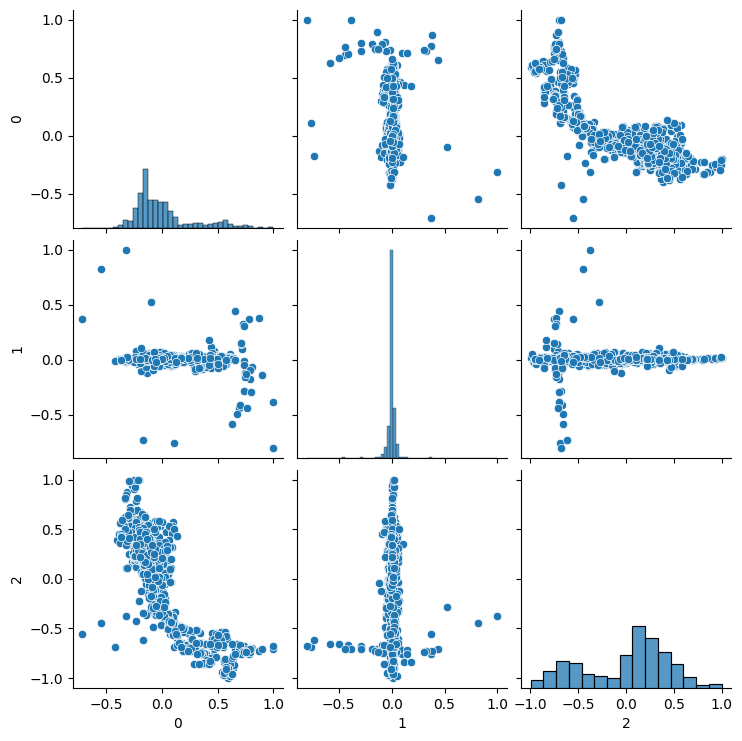

In [21]:
sns.pairplot(data_3_param)

## Get FMLE

In [22]:
d = 3
B_fmle = get_FMLE(data_3_param, d)
evaluate_true_log_likelihood(data_3_param, B_fmle, d, n_grid=10000)

np.float64(-3.4709209436081645)

## Get Data MLE

In [23]:
# Time: 90 secs

max_iter = 5000
min_grad_norm=5e-4
d = 3

B_opt = estimate_optimal_B(data_3_param, degree=d, n_grid=10000, verbosity=1, penalty_lambda = 0, max_iterations = max_iter, min_gradient_norm = min_grad_norm)

Optimizing...
Terminated - min grad norm reached after 2184 iterations, 37.48 seconds.



In [24]:
evaluate_true_log_likelihood(data_3_param, B_opt, d, n_grid=100000)

np.float64(2.42086394243377)

## Run MCMC

In [31]:
# True MLE
samples_df_T = run_mcmc_sampler(data_3_param, B=B_opt, d=d, num_samples=1000, burnin=300, thin=5)

100%|██████████| 1000/1000 [00:00<00:00, 1776.45it/s]


In [26]:
# FMLE
samples_df_F = run_mcmc_sampler(data_3_param, B=B_fmle, d=d, num_samples=1000, burnin=300, thin=5)

100%|██████████| 1000/1000 [00:00<00:00, 1467.88it/s]


## Plot

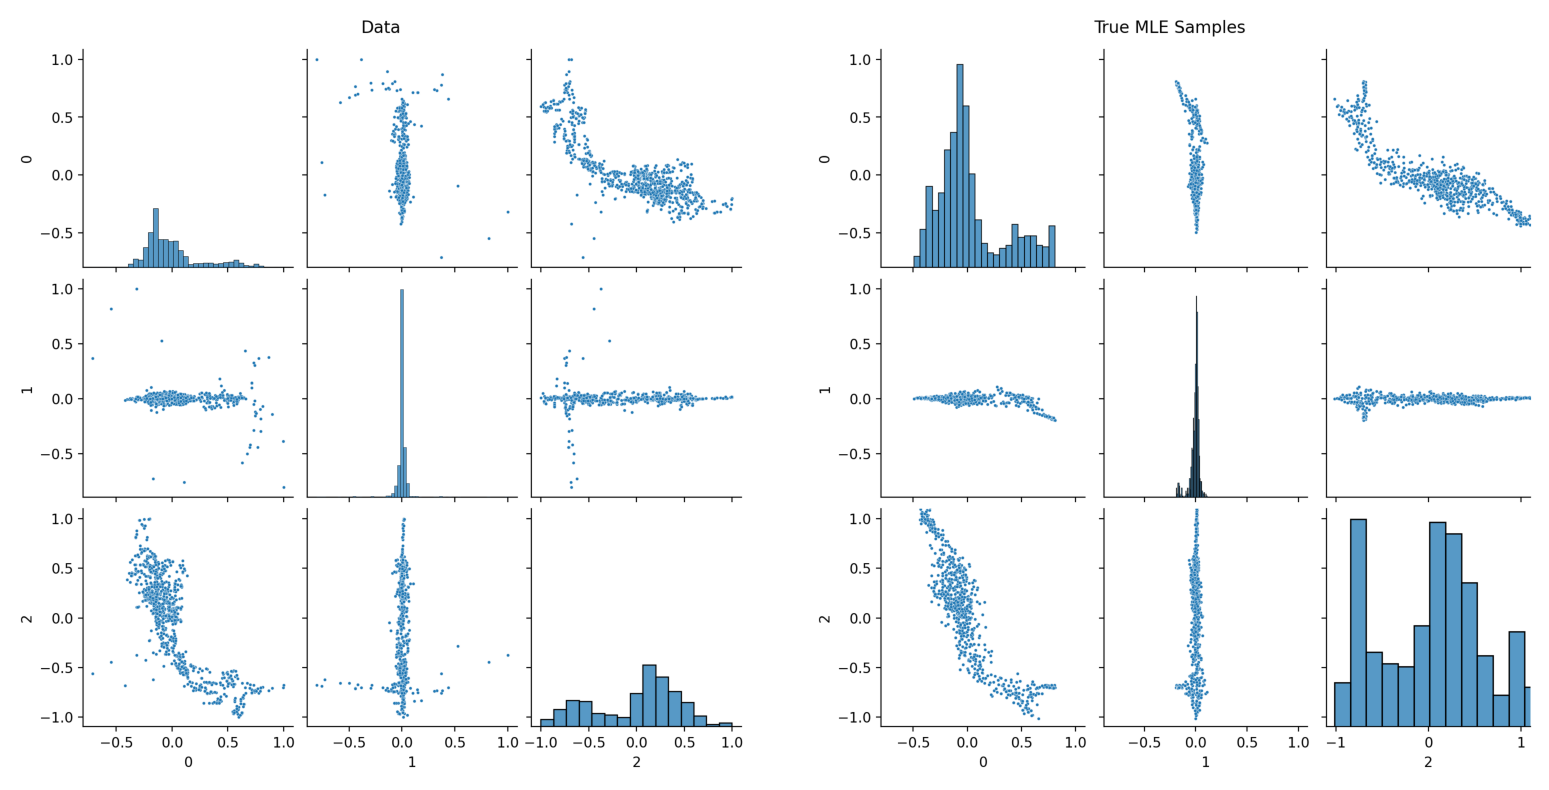

In [32]:
samples = samples_df_T
True_Data = data_3_param
name = "True MLE Samples"

# First pairplot: original data
g1 = sns.pairplot(True_Data, plot_kws={"s": 5})
g1.fig.suptitle("Data", y=1.02)

# Save axis limits
lims = {}
for i, row_axes in enumerate(g1.axes):
    for j, ax in enumerate(row_axes):
        if ax:
            lims[(i, j)] = (ax.get_xlim(), ax.get_ylim())

# Second pairplot: samples
g2 = sns.pairplot(samples, plot_kws={"s": 5})
g2.fig.suptitle(name, y=1.02)

# Apply saved limits
for i, row_axes in enumerate(g2.axes):
    for j, ax in enumerate(row_axes):
        if ax and (i, j) in lims:
            ax.set_xlim(lims[(i, j)][0])
            ax.set_ylim(lims[(i, j)][1])

# Convert both pairplots to images
buf1 = io.BytesIO()
buf2 = io.BytesIO()

g1.fig.savefig(buf1, format="png", bbox_inches="tight", dpi=200)
g2.fig.savefig(buf2, format="png", bbox_inches="tight", dpi=200)

buf1.seek(0)
buf2.seek(0)

img1 = Image.open(buf1)
img2 = Image.open(buf2)

plt.close(g1.fig)
plt.close(g2.fig)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()

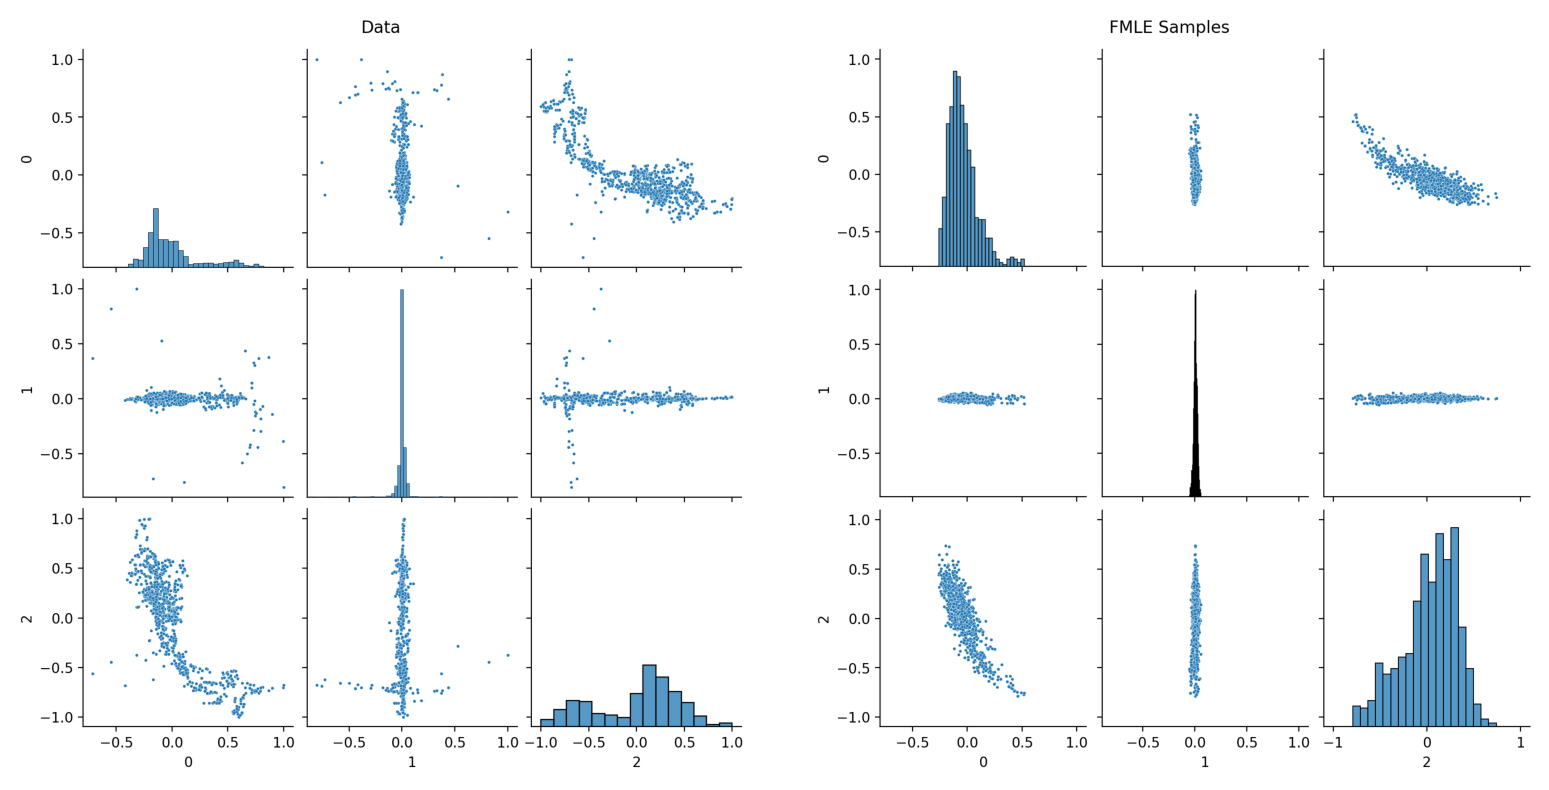

In [28]:
samples = samples_df_F
True_Data = data_3_param
name = "FMLE Samples"

# First pairplot: original data
g1 = sns.pairplot(True_Data, plot_kws={"s": 5})
g1.fig.suptitle("Data", y=1.02)

# Save axis limits
lims = {}
for i, row_axes in enumerate(g1.axes):
    for j, ax in enumerate(row_axes):
        if ax:
            lims[(i, j)] = (ax.get_xlim(), ax.get_ylim())

# Second pairplot: samples
g2 = sns.pairplot(samples, plot_kws={"s": 5})
g2.fig.suptitle(name, y=1.02)

# Apply saved limits
for i, row_axes in enumerate(g2.axes):
    for j, ax in enumerate(row_axes):
        if ax and (i, j) in lims:
            ax.set_xlim(lims[(i, j)][0])
            ax.set_ylim(lims[(i, j)][1])

# Convert both pairplots to images
buf1 = io.BytesIO()
buf2 = io.BytesIO()

g1.fig.savefig(buf1, format="png", bbox_inches="tight", dpi=200)
g2.fig.savefig(buf2, format="png", bbox_inches="tight", dpi=200)

buf1.seek(0)
buf2.seek(0)

img1 = Image.open(buf1)
img2 = Image.open(buf2)

plt.close(g1.fig)
plt.close(g2.fig)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# 5-dim Data

In [35]:
data_5_param = pd.read_csv('data/LOC_data_5_param.csv', header = None)
data_5_param.head()

,0,1,2,3,4
0,0.008034,-0.036382,-0.001357,0.085717,-0.001516
1,-0.121358,-0.075081,-0.060784,-0.007843,0.063148
2,0.060257,0.097179,-0.035781,-0.001448,-0.374995
3,-0.003096,0.055340,0.117145,-0.058935,0.064623
4,0.066649,0.109184,-0.133138,-0.174390,0.202803


In [36]:
d = 2
B_fmle = get_FMLE(data_5_param, d)
evaluate_true_log_likelihood(data_5_param, B_fmle, d, n_grid=10000)

np.float64(-1.5093929303439904)

In [45]:
# Time: 90 secs

max_iter = 5000
min_grad_norm=5e-5
d = 2

B_opt = estimate_optimal_B(data_5_param, degree=d, n_grid=50000, verbosity=2, penalty_lambda = 0, max_iterations = max_iter, min_gradient_norm = min_grad_norm)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +1.2893759476017888e+00    1.86197547e+00    
   2         -3.1835535288630012e-01    1.41643911e+00    
   3         -2.7715585558113913e+00    9.65669680e-01    
   4         -2.8393355202279054e+00    2.98124967e+00    
   5         -3.0962045219298755e+00    2.67459684e+00    
   6         -3.8502432544803247e+00    1.38475592e+00    
   7         -3.9073122616330602e+00    2.35883023e+00    
   8         -4.1108064304455745e+00    1.85852524e+00    
   9         -4.4266410895681894e+00    9.56771658e-01    
  10         -4.4895625206602867e+00    1.19650249e+00    
  11         -4.5900736654448400e+00    6.01842791e-01    
  12         -4.6364363412909144e+00    6.81048612e-01    
  13         -4.6766770709089220e+00    5.84878242e-01    
  14         -4.7117828945990379e+00    6.54858139e-01    
  15         -4.7452707601839421e+00    5.

## Run MCMC

In [46]:
# True MLE
samples_df_T_5 = run_mcmc_sampler(data_5_param, B=B_opt, d=d, num_samples=1000, burnin=300, thin=5)

100%|██████████| 1000/1000 [00:00<00:00, 1112.16it/s]


In [47]:
# FMLE
samples_df_F_5 = run_mcmc_sampler(data_5_param, B=B_fmle, d=d, num_samples=1000, burnin=300, thin=5)

100%|██████████| 1000/1000 [00:00<00:00, 1060.65it/s]


## Plot

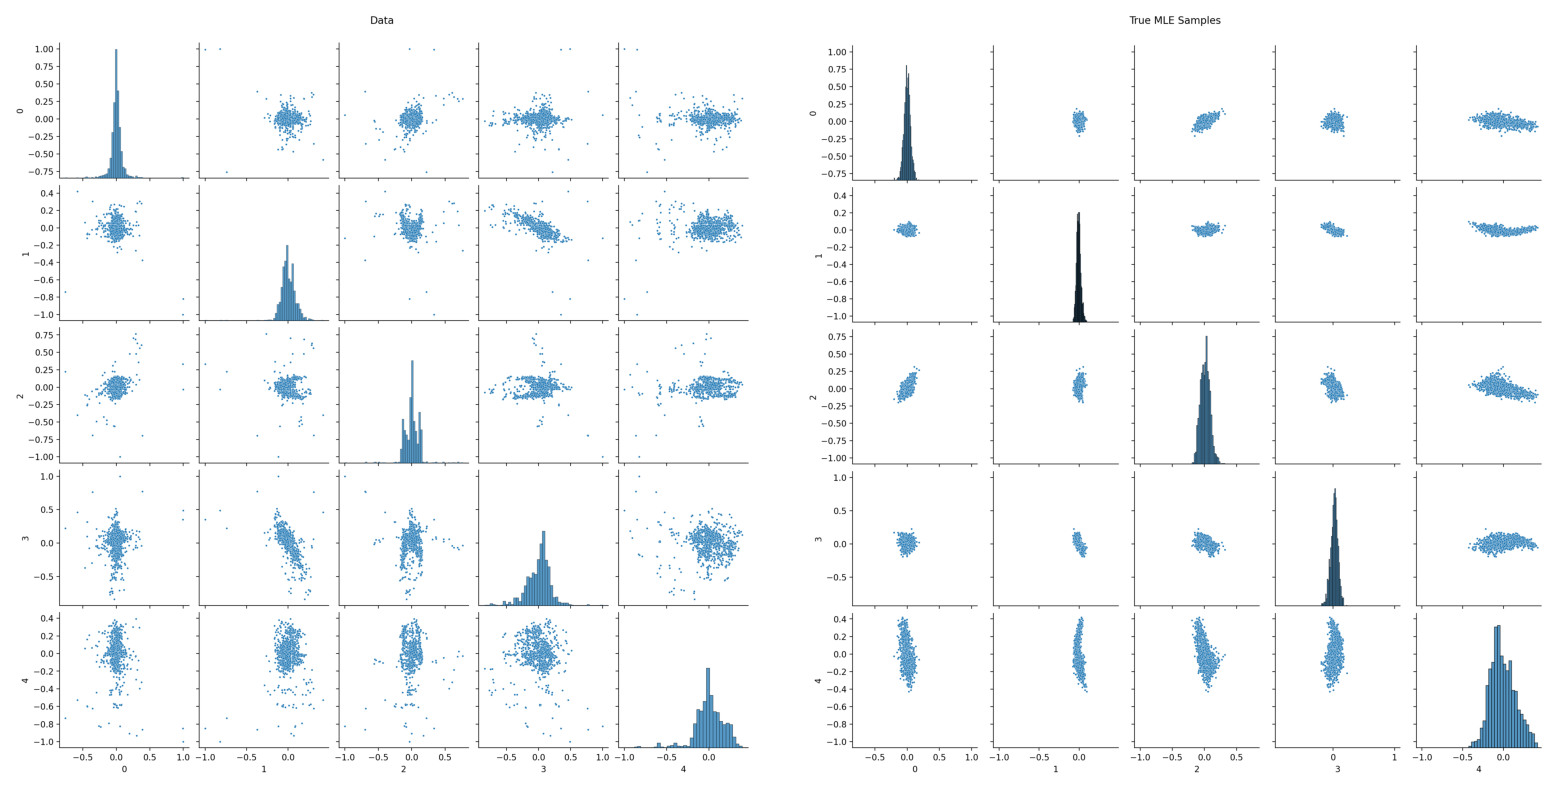

In [48]:
samples = samples_df_T_5
True_Data = data_5_param
name = "True MLE Samples"

# First pairplot: original data
g1 = sns.pairplot(True_Data, plot_kws={"s": 5})
g1.fig.suptitle("Data", y=1.02)

# Save axis limits
lims = {}
for i, row_axes in enumerate(g1.axes):
    for j, ax in enumerate(row_axes):
        if ax:
            lims[(i, j)] = (ax.get_xlim(), ax.get_ylim())

# Second pairplot: samples
g2 = sns.pairplot(samples, plot_kws={"s": 5})
g2.fig.suptitle(name, y=1.02)

# Apply saved limits
for i, row_axes in enumerate(g2.axes):
    for j, ax in enumerate(row_axes):
        if ax and (i, j) in lims:
            ax.set_xlim(lims[(i, j)][0])
            ax.set_ylim(lims[(i, j)][1])

# Convert both pairplots to images
buf1 = io.BytesIO()
buf2 = io.BytesIO()

g1.fig.savefig(buf1, format="png", bbox_inches="tight", dpi=200)
g2.fig.savefig(buf2, format="png", bbox_inches="tight", dpi=200)

buf1.seek(0)
buf2.seek(0)

img1 = Image.open(buf1)
img2 = Image.open(buf2)

plt.close(g1.fig)
plt.close(g2.fig)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()

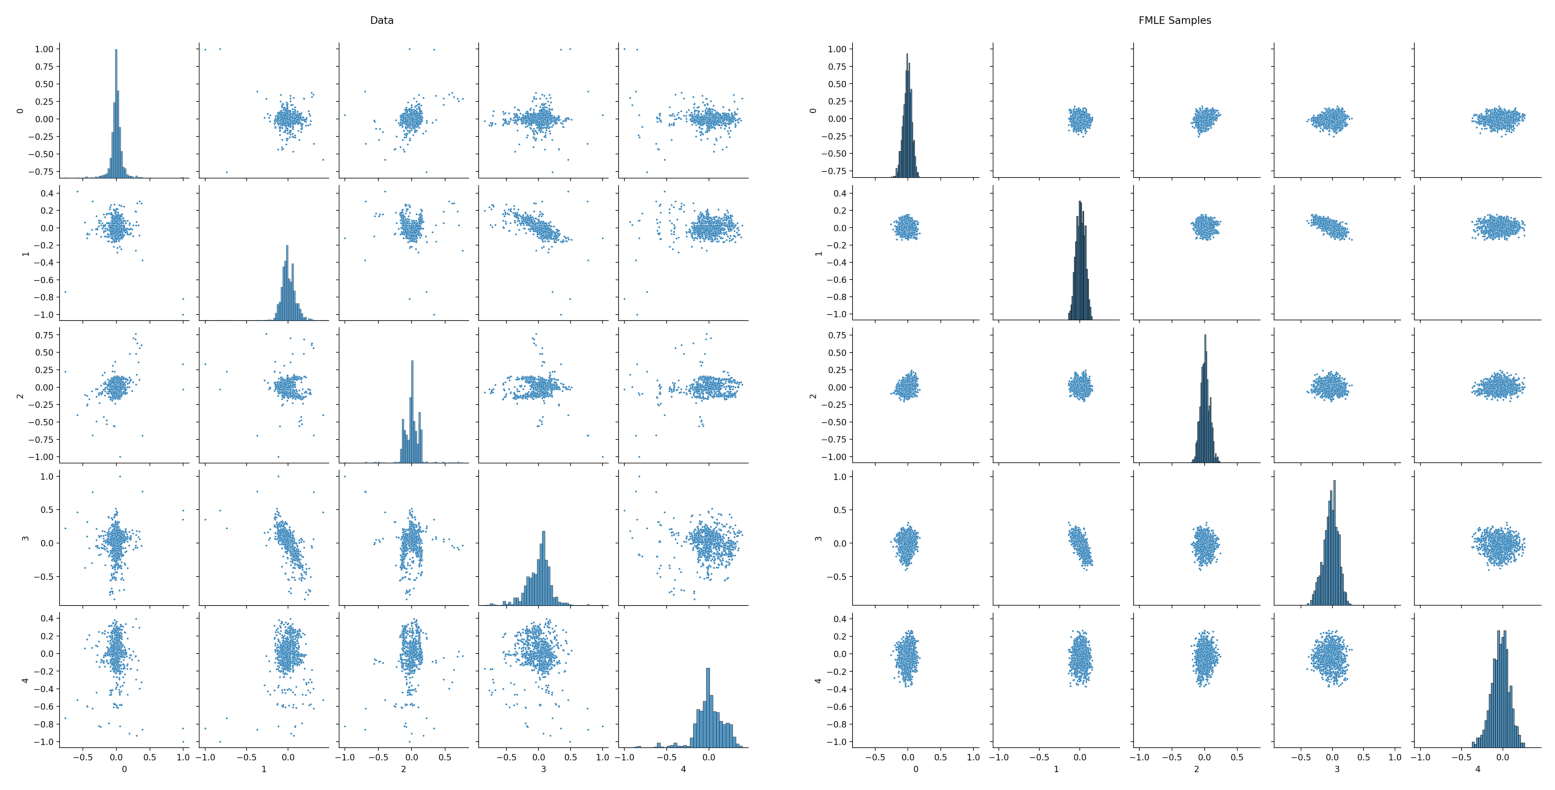

In [49]:
samples = samples_df_F_5
True_Data = data_5_param
name = "FMLE Samples"

# First pairplot: original data
g1 = sns.pairplot(True_Data, plot_kws={"s": 5})
g1.fig.suptitle("Data", y=1.02)

# Save axis limits
lims = {}
for i, row_axes in enumerate(g1.axes):
    for j, ax in enumerate(row_axes):
        if ax:
            lims[(i, j)] = (ax.get_xlim(), ax.get_ylim())

# Second pairplot: samples
g2 = sns.pairplot(samples, plot_kws={"s": 5})
g2.fig.suptitle(name, y=1.02)

# Apply saved limits
for i, row_axes in enumerate(g2.axes):
    for j, ax in enumerate(row_axes):
        if ax and (i, j) in lims:
            ax.set_xlim(lims[(i, j)][0])
            ax.set_ylim(lims[(i, j)][1])

# Convert both pairplots to images
buf1 = io.BytesIO()
buf2 = io.BytesIO()

g1.fig.savefig(buf1, format="png", bbox_inches="tight", dpi=200)
g2.fig.savefig(buf2, format="png", bbox_inches="tight", dpi=200)

buf1.seek(0)
buf2.seek(0)

img1 = Image.open(buf1)
img2 = Image.open(buf2)

plt.close(g1.fig)
plt.close(g2.fig)

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()